# Dane titanic

## Wczytanie danych

In [579]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [580]:
# wczytanie bibliotek
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
base_path = Path('/content/drive/MyDrive') # change to path folder with data

Zbiór danych titanic zawiera wybrane charakterystyki opisujące pasażerów Titanica (w tym m.in. takie zmienne jak: wiek, płeć, miejsce rozpoczęcia podróży czy klasa pasażerska) wraz z informacją czy dana osoba przeżyła katastrofę (zmienna Survived, która jest naszą zmienną predykowaną)


Poniżej tabela z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [581]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId') # wczytanie danych

In [582]:
titanic_df['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

## Podstawowe informacje o danych

In [583]:
titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [584]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      793 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [585]:
titanic_df.shape

(891, 11)

W zbiorze znajduje się 891 obserwacji i 12 cech.

In [586]:
titanic_df.describe() # podstawowe wskaźniki statystyczne dla zmiennych numerycznych

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,793.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,33.123938
std,0.486592,0.836071,14.526497,1.102743,0.806057,51.578312
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.925000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.500000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.275000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [587]:
titanic_df.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,98
Cabin,687


In [588]:
missing_percent = titanic_df.isnull().sum() / len(titanic_df) * 100
missing_percent

,0
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,10.998878
Cabin,77.104377


W zbiorze występują braki dla zmiennej Age, Fare, Cabin i Embarked. Najwięcej braków występuje dla Cabin.


In [589]:
titanic_df.Survived.value_counts(normalize=True)

,proportion
Survived,
0,0.616162
1,0.383838


## Przygotowanie danych

In [590]:
titanic_df.nunique()

,0
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,236
Cabin,147


Zmienne Name, Ticket, Cabin pełnią rolę identyfikatorów, więc je usuwamy, bo nie będą one przydatne w analizie. Zmienne Sex, Embarked zamieniamy na typ categorical, a Pclass na ordered
categorical.

In [591]:
# usunięcie zmiennych pełniących rolę identyfikatorów
titanic_df = titanic_df.drop(columns=["Name", "Ticket", "Cabin"])

# zmiana typów zmiennych
#titanic_df["Survived"] = titanic_df["Survived"].astype("category")
titanic_df["Sex"] = titanic_df["Sex"].astype("category")
titanic_df["Embarked"] = titanic_df["Embarked"].astype("category")
titanic_df["Pclass"] = pd.Categorical(titanic_df["Pclass"], categories=[1, 2, 3], ordered=True)

Poniżej widzimy poziomy zmiennych po konwersji

In [592]:
titanic_df.nunique()

,0
Survived,2
Pclass,3
Sex,2
Age,88
SibSp,7
Parch,7
Fare,236
Embarked,3


oraz typy zmiennych po konwersji

In [593]:
titanic_df.dtypes

,0
Survived,int64
Pclass,category
Sex,category
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Embarked,category


Wartości brakujące dla zmiennej Age i Fare zastępujemy medianą, zaś braki dla zmiennej Embarked wystąpiły tylko dla dwóch obserwacji, zastępujemy je dominantą.

In [594]:
titanic_df["Embarked"] = titanic_df["Embarked"].fillna(titanic_df["Embarked"].mode()[0])
titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].median())
titanic_df["Fare"] = titanic_df["Fare"].fillna(titanic_df["Fare"].median())

In [595]:
titanic_df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [596]:
# dodajemy nowe zmienne, które mogą być przydatne w analizie
titanic_df["FamilySize"] = titanic_df["SibSp"] + titanic_df["Parch"] + 1 # liczba członków rodziny na pokładzie
titanic_df["IsChild"] = titanic_df["Age"] < 18 # czy pasażer jest dzieckiem
titanic_df["IsChild"] = titanic_df["IsChild"].astype("category")
titanic_df.dtypes

,0
Survived,int64
Pclass,category
Sex,category
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Embarked,category
FamilySize,int64
IsChild,category


In [597]:
numeric_cols = titanic_df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = numeric_cols.drop('Survived')
categorical_cols = titanic_df.select_dtypes(include=['object', 'category']).columns

In [598]:
for column in categorical_cols:
    print(titanic_df[column].value_counts())

Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Sex
male      577
female    314
Name: count, dtype: int64
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64
IsChild
False    778
True     113
Name: count, dtype: int64


Nie zauważamy jakichś nietypowych, rzadko występujących kategorii.

## Wizualizacja zmiennych

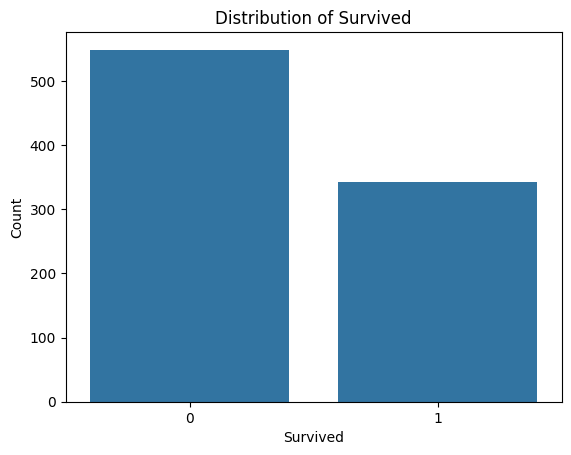

In [599]:
sns.countplot(x='Survived', data=titanic_df)
plt.title('Distribution of Survived')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

Większość pasażerów nie przeżyła katastrofy. Zginęło około 550 osób, zaś przeżyło około 350.

### Histogramy dla zmiennych numerycznych

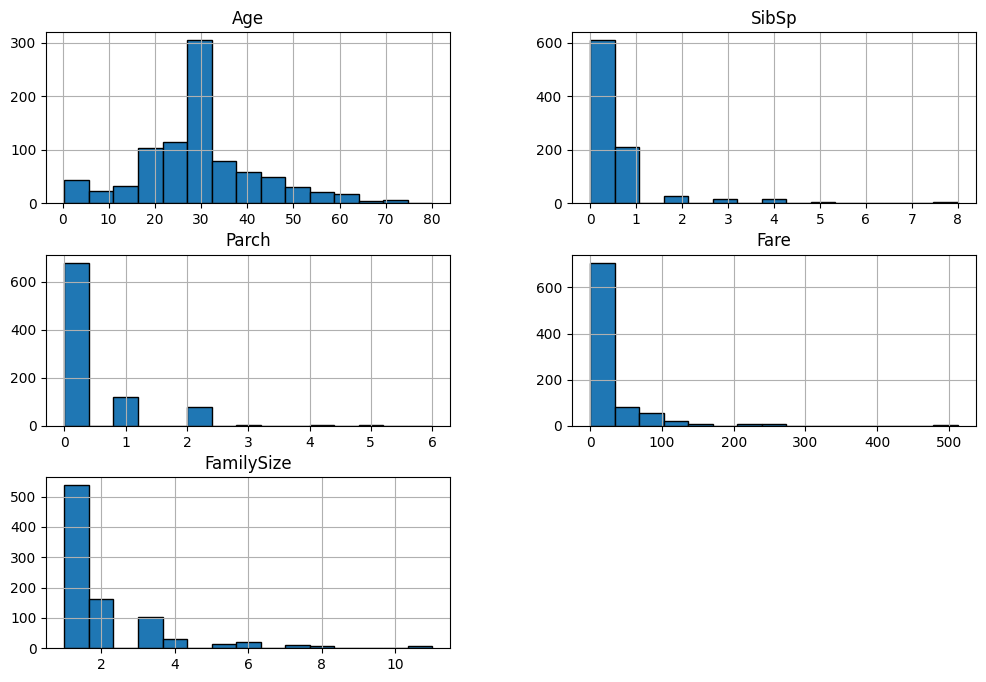

In [600]:
titanic_df[numeric_cols].hist(figsize=(12, 8), bins=15, edgecolor='black')
plt.show()

**Age**: Najwięcej pasażerów plasuje się w przedziale 20-30 lat, jednak szczyt w okolicach 30 jest skutkiem naszego uzupełnienia braków medianą.

**SibSp**: Zdecydowana większość pasażerów (ponad 600 osób) podróżowała bez rodzeństwa ani małżonka (0). Około 200 osób podróżowało z jedną osobą, a wyższe wartości występują bardzo rzadko.

**Parch**: Zdecydowana większość pasażerów podróżowała bez rodziców i dzieci. Wartości 1 i 2 występują sporadycznie, a ponad 2 bardzo rzadko.

**Fare**: Większość biletów została zakupiona w niskich cenach, wysokie wartości występują rzadko.

**FamilySize**: Większość pasażerów podróżowała samodzielnie (FamilySize równe 1), wyższe wartości występuje znacznie rzadziej.

Zmienne SibSp, Parch, Fare, FamilySize mają rozkład prawostronnie skośny.

### Wykresy słupkowe dla zmiennych kategorycznych

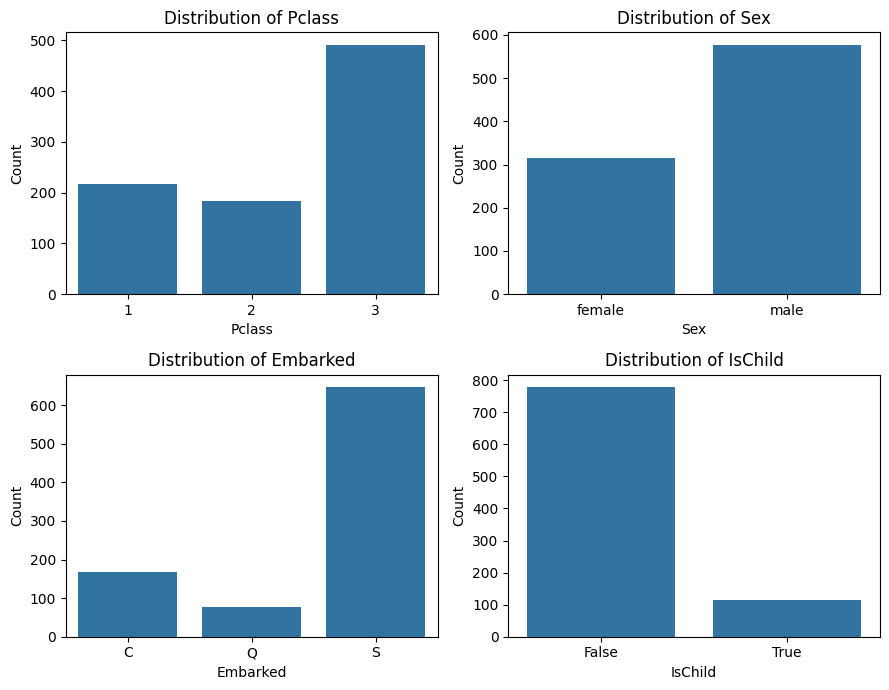

In [601]:
plt.figure(figsize=(9, 7))

for idx, column in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, idx)
    sns.countplot(x=column, data=titanic_df)
    plt.title(f'Distribution of {column}')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()


**Pclass**: Większość pasażerów podróżowała w 3 klasie (prawie 500), a pozostałe klasy (1 i 2) miały zbliżoną do siebie ilość pasażerów (około 200).

**Sex**: Większość podróżnych to byli mężczyźni (ok. 580), a kobiet było tylko nieco ponad 300.

**Embarked**: Zdecydowana większość pasażerów wsiadła w Southampton (ponad 600 osób). W Cherbourgu (C) wsiadło około 170 osób, a najmniej w Queenstown (Q) - poniżej 100 osób.

**IsChild**: Większość pasażerów była dorosła (prawie 800 osób), dzieci stanowiły niewielką część podróżujących (około 100 osób).


## Survived a pozostałe zmienne

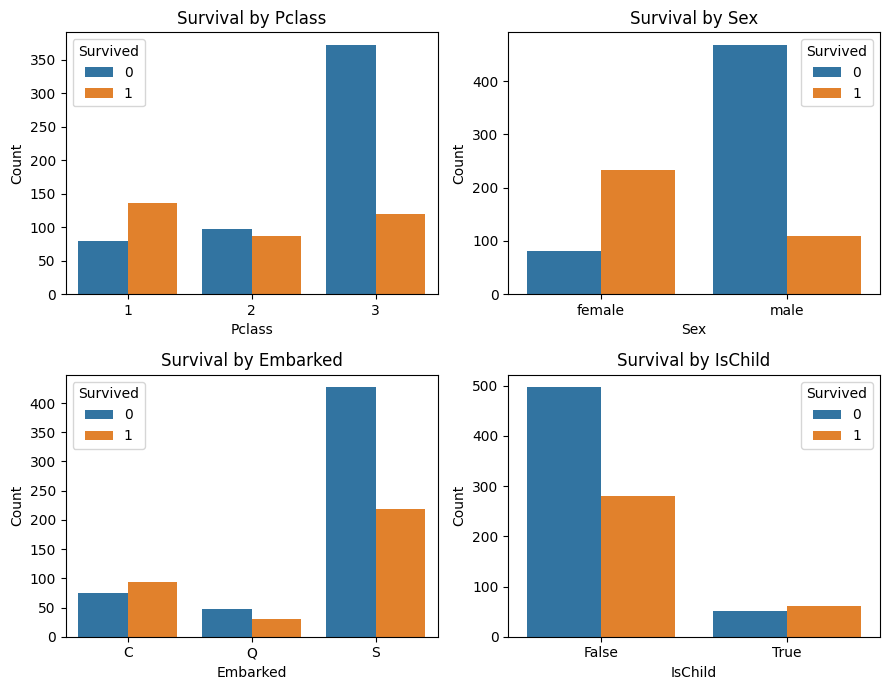

In [602]:
plt.figure(figsize=(9, 7))
for idx, column in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, idx)
    sns.countplot(data=titanic_df, x=column, hue='Survived')
    plt.title(f'Survival by {column}')
    plt.xlabel(column)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

**Sex**: kobiety znacznie częściej przeżywały katastrofę niż mężczyźni. Większość kobiet przeżyła, zaś u mężczyzn odwrotnie - większość zginęła.

**Pclass**: wyższa klasa wiązała się z większą szansą na przeżycie. W klasie 3 zdecydowana większość pasażerów zginęła, w drugiej jest to dość wyrównane, a w klasie 1 większość przeżyła.

**Embarked**: większosć pasażerów, którzy wsiedli w Southampton oraz Queenstown, zginęła w katastrofie. W przypadku osób, które wsiadły w Cherbourgu, liczba osób, które przeżyły, jest większa w stosunku do tych, które zginęły.

**IsChild**: wśród dorosłych zdecydowana większość zginęła w katastrofie. U dzieci występuje nieznaczna przewaga osób, które przeżyły.


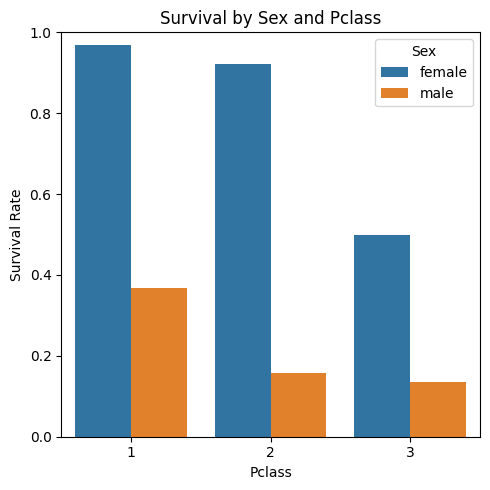

In [603]:
survival_by_sex_class = (titanic_df.groupby(['Pclass', 'Sex'], observed=True)['Survived'].mean().reset_index())

plt.figure(figsize=(5,5))
sns.barplot(data=survival_by_sex_class, x='Pclass', y='Survived', hue='Sex')
plt.title('Survival by Sex and Pclass')
plt.xlabel('Pclass')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

Kobiety przeżywały znacznie częściej niż mężczyźni niezależnie od klasy biletu. Wraz ze wzrostem wartości Pclass przeżywalność była niższa. Zatem płeć oraz klasa biletu były czynnikami, które były mocno związane z przeżywalnością. Największą szansę na przeżycie miały kobiety z klasy 1.

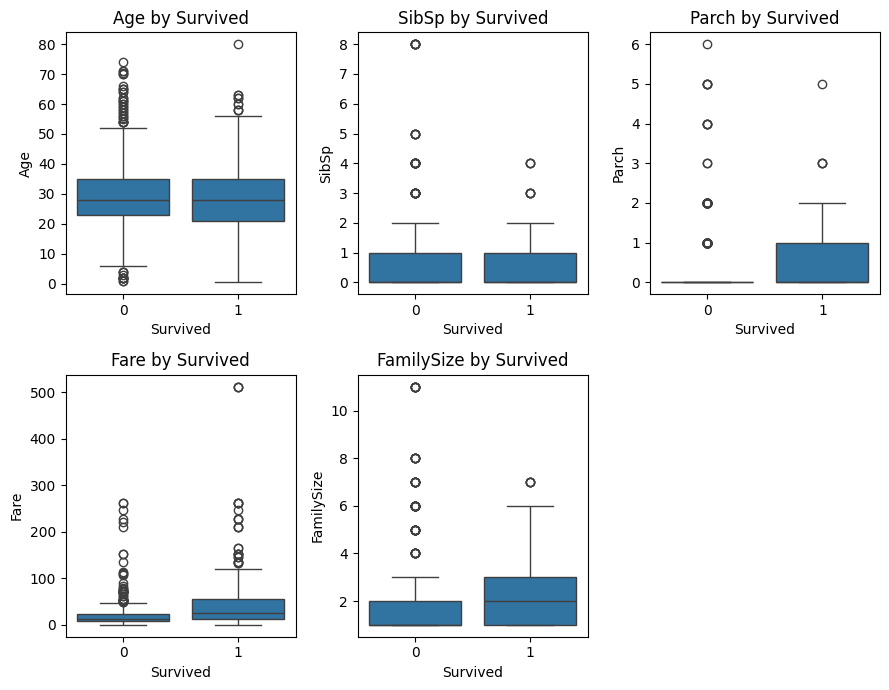

In [604]:
plt.figure(figsize=(9,7))

for idx, column in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, idx)
    sns.boxplot(data=titanic_df, x='Survived', y=column)
    plt.title(f'{column} by Survived')
    plt.xlabel('Survived')
    plt.ylabel(column)

plt.tight_layout()
plt.show()

Na podstawie boxplotów możemy zauważyć, że w zbiorze występują wartości odstające. Mimo to, zakresy zmiennych wydają się być normalne.


## Wartości odstające

In [605]:
outlier_counts = {}
outlier_percent = {}
for column in numeric_cols:
    Q1 = titanic_df[column].quantile(0.25)
    Q3 = titanic_df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = titanic_df[(titanic_df[column] < lower_bound) | (titanic_df[column] > upper_bound)]
    outlier_counts[column] = len(outliers)
    outlier_percent[column] = len(outliers) / len(titanic_df) * 100
outlier_counts

{'Age': 66, 'SibSp': 46, 'Parch': 213, 'Fare': 110, 'FamilySize': 91}

In [606]:
outlier_percent

{'Age': 7.4074074074074066,
 'SibSp': 5.16273849607183,
 'Parch': 23.905723905723907,
 'Fare': 12.345679012345679,
 'FamilySize': 10.21324354657688}

W zbiorze mamy sporo wartości odstających, jednak większość z nich wydaje się być naturalnym zjawiskiem, dlatego ich nie usuwamy.

## Kodowanie zmiennych kategorycznych

In [607]:
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})
titanic_df['IsChild'] = titanic_df['IsChild'].astype(int)
titanic_df = pd.get_dummies(titanic_df, columns=['Embarked'], drop_first=True, dtype=int) #one-hot encoding dla zmiennej Embarked
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsChild,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,2,0,0,1
2,1,1,1,38.0,1,0,71.2833,2,0,0,0
3,1,3,1,26.0,0,0,7.9250,1,0,0,1
4,1,1,1,35.0,1,0,53.1000,2,0,0,1
5,0,3,0,35.0,0,0,8.0500,1,0,0,1


## Macierz korelacji

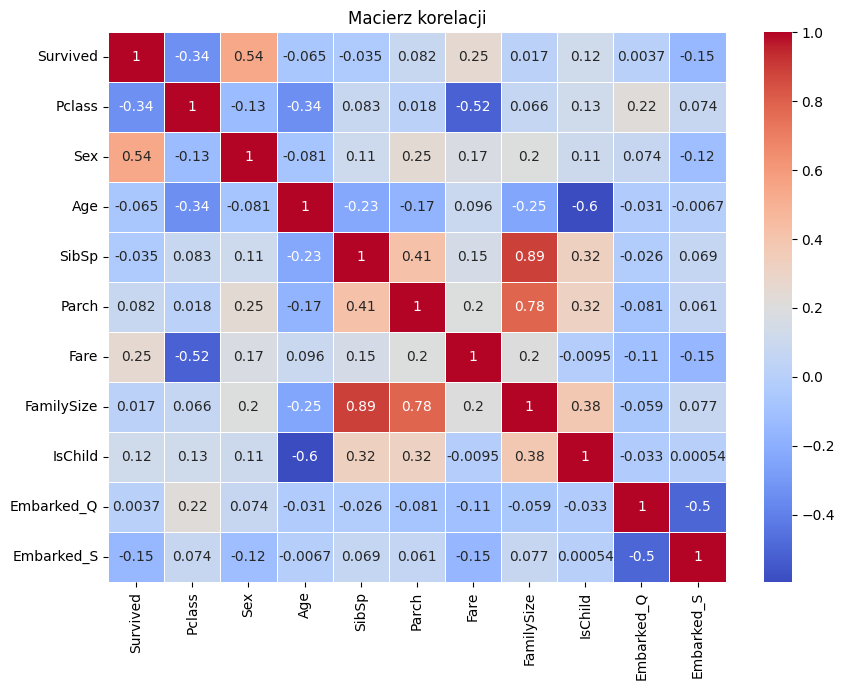

In [608]:
corr = titanic_df.corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Macierz korelacji')
plt.tight_layout()
plt.show()

Zmienna **Survived** jest ujemnie skorelowana z **Pclass**, co oznacza zależność między klasą biletu a przeżywalnością. Podróżujący klasą o wyższym numerze (3) mieli mniejszą przeżywalność, niż ci z klasy 1 czy 2. Występuje również dodatnia korelacja **Survived** z **Fare**, czyli osoby z droższymi biletami częściej przeżywały katastrofę. Nie ma praktycznie żadnej korelacji między **Survived** a liczbą osób z rodziny, z którymi pasażer podróżował.

## Wnioski
Na podstawie analizy możemy zauważyć, że płeć była jednym z czynników wpływających na przeżywalność pasażerów. Kobiety znacznie częściej przeżywały katastrofę niż mężczyźni. Kolejną analizowaną cechą jest klasa biletu pasażera. Osoby podróżujące w wyższych klasach, tzn. przy niższej wartości Pclass (która wiąże się również z wyższą ceną biletu) charakteryzowały się znacznie większą przeżywalnością. Najniższą przeżywalność obserwujemy w klasie 3, a największą w klasie 1.

In [609]:
titanic_df.info()
titanic_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    891 non-null    int64   
 1   Pclass      891 non-null    category
 2   Sex         891 non-null    category
 3   Age         891 non-null    float64 
 4   SibSp       891 non-null    int64   
 5   Parch       891 non-null    int64   
 6   Fare        891 non-null    float64 
 7   FamilySize  891 non-null    int64   
 8   IsChild     891 non-null    int64   
 9   Embarked_Q  891 non-null    int64   
 10  Embarked_S  891 non-null    int64   
dtypes: category(2), float64(2), int64(7)
memory usage: 71.6 KB


,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
FamilySize,0
IsChild,0
Embarked_Q,0
